<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [4]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_length))

model.add(LSTM(128))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 255s 646ms/step - accuracy: 0.7801 - loss: 0.4525 - val_accuracy: 0.8586 - val_loss: 0.3264
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 281s 718ms/step - accuracy: 0.8977 - loss: 0.2655 - val_accuracy: 0.8699 - val_loss: 0.3287
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 259s 663ms/step - accuracy: 0.9230 - loss: 0.2042 - val_accuracy: 0.8709 - val_loss: 0.3398
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 300s 760ms/step - accuracy: 0.9445 - loss: 0.1482 - val_accuracy: 0.8662 - val_loss: 0.3624
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 273s 699ms/step - accuracy: 0.9503 - loss: 0.1344 - val_accuracy: 0.8658 - val_loss: 0.4060


In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.8658 - loss: 0.4060
Test Accuracy: 0.8658400177955627


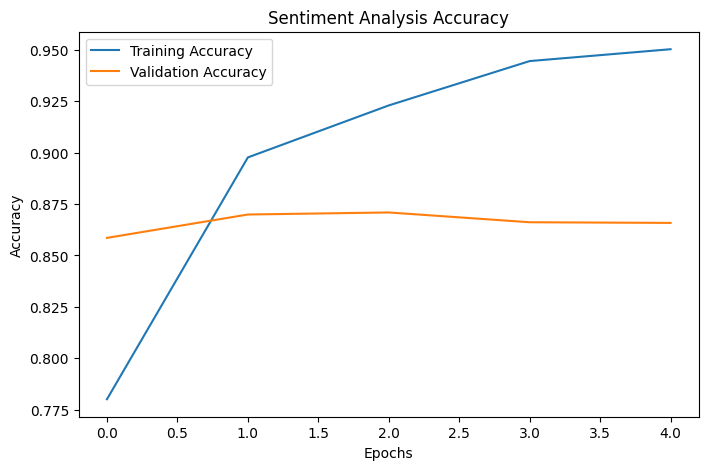

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Sentiment Analysis Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()